In [ ]:
import scipy.io
import numpy as np
import mne
import matplotlib.pyplot as plt
import addcopyfighandler
%matplotlib qt

import mne
from mne.viz import plot_topomap

Channels marked as bad:
none
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [2]:
# mat file 불러오기
mat = scipy.io.loadmat(r'\\HCN-NAS\ywYang\s14000.mat')
print(mat.keys())
fields = list(mat['eeg'][0].dtype.fields.keys())
print(fields)

dict_keys(['__header__', '__version__', '__globals__', 'eeg'])
['raw_left', 'raw_right', 'n_trials', 'frame', 'srate', 'event', 'senloc', 'psenloc', 'subject', 'comment', 'emg_left', 'emg_right', 'rest', 'noise']


In [3]:
#eeg 채널 이름 정의
eeg_ch_names = [
   "Fp1", "AF7", "AF3", "F1", "F3", "F5", "F7", "FT7", "FC5", "FC3", "FC1",
    "C1", "C3", "C5", "T7", "TP7", "CP5", "CP3", "CP1", "P1", "P3", "P5", "P7",
    "P9", "PO7", "PO3", "O1", "Iz", "Oz", "POz", "Pz", "CPz", "Fpz", "Fp2",
    "AF8", "AF4", "AFz", "Fz", "F2", "F4", "F6", "F8", "FT8", "FC6", "FC4",
    "FC2", "FCz", "Cz", "C2", "C4", "C6", "T8", "TP8", "CP6", "CP4", "CP2",
    "P2", "P4", "P6", "P8", "P10", "PO8", "PO4", "O2",
]
#emg 채널 이름 정의
emg_ch_names = ["EMG1", "EMG2", "EMG3", "EMG4"]

#sampling frequency
sampling_freq = 512

In [4]:
raw_left = mne.io.RawArray(
    mat['eeg'][0]['raw_left'][0] * 1e-6 / 32,
    mne.create_info(eeg_ch_names, sampling_freq, 'eeg')
)

raw_left.add_channels([
    mne.io.RawArray(
        mat['eeg'][0]['emg_left'][0] * 1e-6 / 32,
        mne.create_info(emg_ch_names, sampling_freq, 'emg')
    )
])

raw_left.add_channels([
    mne.io.RawArray(
        mat['eeg'][0]['event'][0],
        mne.create_info(['event'], sampling_freq, 'stim')
    )
])

Creating RawArray with float64 data, n_channels=64, n_times=358400
    Range : 0 ... 358399 =      0.000 ...   699.998 secs
Ready.
Creating RawArray with float64 data, n_channels=4, n_times=358400
    Range : 0 ... 358399 =      0.000 ...   699.998 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=358400
    Range : 0 ... 358399 =      0.000 ...   699.998 secs
Ready.


<RawArray | 69 x 358400 (700.0 s), ~188.7 MiB, data loaded>

In [5]:
raw_right = mne.io.RawArray(
    mat['eeg'][0]['raw_right'][0] * 1e-6 / 32,
    mne.create_info(eeg_ch_names, sampling_freq, 'eeg')
)

raw_right.add_channels([
    mne.io.RawArray(
        mat['eeg'][0]['emg_right'][0] * 1e-6 / 32,
        mne.create_info(emg_ch_names, sampling_freq, 'emg')
    )
])

raw_right.add_channels([
    mne.io.RawArray(
        mat['eeg'][0]['event'][0],
        mne.create_info(['event'], sampling_freq, 'stim')
    )
])

Creating RawArray with float64 data, n_channels=64, n_times=358400
    Range : 0 ... 358399 =      0.000 ...   699.998 secs
Ready.
Creating RawArray with float64 data, n_channels=4, n_times=358400
    Range : 0 ... 358399 =      0.000 ...   699.998 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=358400
    Range : 0 ... 358399 =      0.000 ...   699.998 secs
Ready.


<RawArray | 69 x 358400 (700.0 s), ~188.7 MiB, data loaded>

In [6]:
raw = [raw_left, raw_right]

LEFT = 0
RIGHT = 1

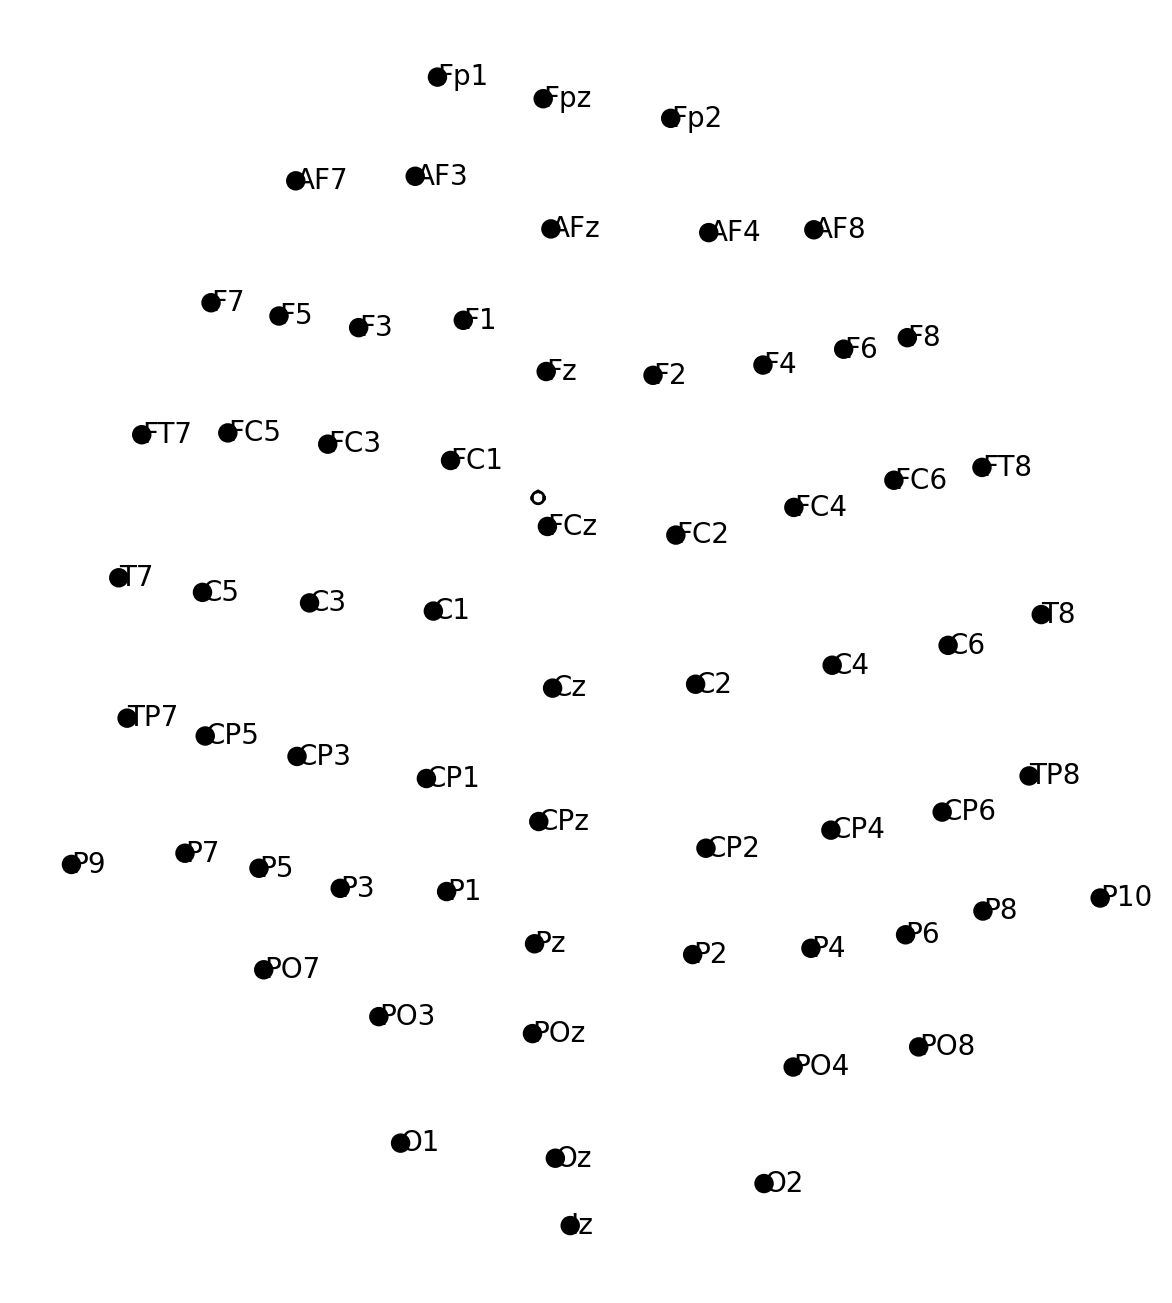

In [8]:
#senloc
senloc = mat['eeg'][0]['senloc'][0]

ch_pos = {name: senloc[i] for i, name in enumerate(eeg_ch_names)}
montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame="head")

raw[LEFT].set_montage(montage, on_missing="ignore")
raw[RIGHT].set_montage(montage, on_missing="ignore")

raw[LEFT].plot_sensors(kind = "topomap", ch_type = "eeg", show_names=True)
raw[RIGHT].plot_sensors(kind = "topomap", ch_type = "eeg", show_names=True)


In [9]:
# band pass filtering
raw[LEFT].filter(l_freq= 8, h_freq = 30)
raw[RIGHT].filter(l_freq = 8, h_freq = 30)

# notch filtering
raw[LEFT].notch_filter(freqs = 60)
raw[RIGHT].notch_filter(freqs = 60)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 845 samples (1.650 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30

<RawArray | 69 x 358400 (700.0 s), ~188.7 MiB, data loaded>

In [10]:
# re-referencing
raw[LEFT].set_eeg_reference("average", projection = False)
raw[RIGHT].set_eeg_reference("average", projection = False)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawArray | 69 x 358400 (700.0 s), ~188.7 MiB, data loaded>

In [11]:
raw[LEFT].plot(title = "Left")
raw[RIGHT].plot(title = "Right")

Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x2663b8ce4c0) at 0x0000026628446340>

In [12]:
#events 추출하기
le = mne.find_events(raw[LEFT])
re = mne.find_events(raw[RIGHT])
events = [le, re]

Finding events on: event
100 events found on stim channel event
Event IDs: [1]
Finding events on: event
100 events found on stim channel event
Event IDs: [1]


In [13]:

#Epochs 만들기
le = mne.Epochs(raw[LEFT],
                events[LEFT],
                tmin = -2, tmax = 5, 
                picks = ("C3", "C4"),
                baseline = None,
                preload=True,)
re = mne.Epochs(raw[RIGHT],
                events[RIGHT],
                tmin = -2, tmax = 5,
                picks = ["C3", "C4"],
                baseline = None,
                preload = True,)
epochs = [le, re]

Not setting metadata
100 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 100 events and 3585 original time points ...
1 bad epochs dropped
Not setting metadata
100 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 100 events and 3585 original time points ...
1 bad epochs dropped


In [14]:
#epochs 시각화
epochs[LEFT].plot(n_epochs=2,title="Left Epochs")
epochs[RIGHT].plot(n_epochs=2 ,title= "Right Epochs")

<mne_qt_browser._pg_figure.MNEQtBrowser(0x2663bbe6370) at 0x00000266284A9FC0>

In [15]:
evoked_left = (
    epochs[LEFT]
    .copy()
    .apply_hilbert(envelope=True) #힐베르트 변환을 거친 복소수 신호의 절댓값
    .average()
)

evoked_right = (
    epochs[RIGHT]
    .copy()
    .apply_hilbert(envelope=True)
    .average()
)

evoked = [evoked_left, evoked_right]

In [16]:
# baseline 구간
baseline = (-0.5, 0)

# baseline index 계산
times = evoked[LEFT].times
baseline_idx = (times >= baseline[0]) & (times <= baseline[1])

In [ ]:
#A, R 생성
A_l = evoked[LEFT].data
A_r = evoked[RIGHT].data

R_l = A_l[:, baseline_idx].mean(axis=1, keepdims=True)
#A_L의 모든 행과 baseline_idx를 행 방향으로 averaging(2차원 차원 유지하게끔 keepdims = True)
R_r = A_r[:, baseline_idx].mean(axis=1, keepdims=True)

In [18]:
# ERD 객체 생성
erd_left = evoked[LEFT].copy()
erd_right = evoked[RIGHT].copy()

#ERD/ERS Quantification
erd_left.data = ((A_l - R_l) / R_l) * 100
erd_right.data = ((A_r - R_r) / R_r) * 100

In [24]:
#시각화할 채널의 데이터와 인덱스 추출
c3_idx_l = erd_left.ch_names.index("C3")
c4_idx_l = erd_left.ch_names.index("C4")
times_l = erd_left.times

c3_idx_r = erd_right.ch_names.index("C3")
c4_idx_r = erd_right.ch_names.index("C4")
times_r = erd_right.times


plt.figure(figsize=(10, 5))

# 한 공간에 연속으로 plot을 호출하면 선이 겹쳐서 그려짐.
plt.plot(times_l, erd_left.data[c3_idx_l, :], color="blue", label="Left C3 Channel", linewidth=2)
plt.plot(times_l, erd_left.data[c4_idx_l, :], color="orange", label="Left C4 Channel", linewidth=2)

plt.axvline(0, color="k", linestyle="--", alpha=0.5, label="Event")
plt.axvspan(-0.5, 0, color="gray", alpha=0.1, label="Baseline")

plt.title("Left ERD/ERS (%) Comparison", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Percentage (%)")
plt.legend() # 라벨 표기
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))

# 한 공간에 연속으로 plot을 호출하면 선이 겹쳐서 그려짐.
plt.plot(times_r, erd_right.data[c3_idx_r, :], color="blue", label="Right C3 Channel", linewidth=2)
plt.plot(times_r, erd_right.data[c4_idx_r, :], color="orange", label="Right C4 Channel", linewidth=2)

plt.axvline(0, color="k", linestyle="--", alpha=0.5, label="Event")
plt.axvspan(-0.5, 0, color="gray", alpha=0.1, label="Baseline")

plt.title("Right ERD/ERS (%) Comparison", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Percentage (%)")
plt.legend() # 라벨 표시
plt.grid(True)
plt.show()

In [20]:
# ===== Topomap 전용 파이프라인 (64채널) =====
le_topo = mne.Epochs(raw[LEFT], events[LEFT],
                     tmin=-2, tmax=5,
                     picks="eeg",       # 64채널 전부
                     baseline=None, preload=True)
re_topo = mne.Epochs(raw[RIGHT], events[RIGHT],
                     tmin=-2, tmax=5,
                     picks="eeg",
                     baseline=None, preload=True)

# Hilbert → magnitude → 평균
ml_topo = le_topo.copy().apply_hilbert(envelope=True).get_data(copy=True).mean(axis=0)
mr_topo = re_topo.copy().apply_hilbert(envelope=True).get_data(copy=True).mean(axis=0)

# Evoked로 변환
evk_l_topo = mne.EvokedArray(ml_topo, info=le_topo.info, tmin=le_topo.tmin)
evk_r_topo = mne.EvokedArray(mr_topo, info=re_topo.info, tmin=re_topo.tmin)

# Baseline (-0.5 ~ 0 s)
times = evk_l_topo.times
baseline = (times >= -0.5) & (times <= 0.0)

A_l, A_r = evk_l_topo.data, evk_r_topo.data
R_l = A_l[:, baseline].mean(axis=1, keepdims=True)
R_r = A_r[:, baseline].mean(axis=1, keepdims=True)

erd_left_topo  = evk_l_topo.copy()
erd_right_topo = evk_r_topo.copy()
erd_left_topo.data  = (A_l - R_l) / R_l * 100
erd_right_topo.data = (A_r - R_r) / R_r * 100

print("LEFT  min/max/mean:", erd_left_topo.data.min(), erd_left_topo.data.max(), erd_left_topo.data.mean())
print("RIGHT min/max/mean:", erd_right_topo.data.min(), erd_right_topo.data.max(), erd_right_topo.data.mean())


Not setting metadata
100 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 100 events and 3585 original time points ...
1 bad epochs dropped
Not setting metadata
100 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 100 events and 3585 original time points ...
1 bad epochs dropped
LEFT  min/max/mean: -63.737067985925755 319.6457353824879 -10.249091826455928
RIGHT min/max/mean: -59.766785973538695 337.1866038637902 -11.175774733811293


In [21]:
erd_left_topo.set_montage("biosemi64")
erd_right_topo.set_montage("biosemi64")

<Evoked | '' (average, N=1), -2 – 5 s, baseline off, 64 ch, ~1.8 MiB>

In [22]:
topo_times = np.arange(0.5, 2.01, 0.5)

fig_l = erd_left_topo.plot_topomap(
    times=topo_times, ch_type="eeg", cmap="hot",
)
fig_l.suptitle("Left MI — ERD/ERS (%)")

fig_r = erd_right_topo.plot_topomap(
    times=topo_times, ch_type="eeg", cmap="hot",
    contours=4,
)
fig_r.suptitle("Right MI — ERD/ERS (%)")

plt.show()
print(erd_right_topo.data)

[[156.78053435 234.95678019 253.29959206 ... 264.81766183 241.16284903
  197.42590336]
 [ 81.91335869 136.79039352 147.3643148  ... 160.72279967 143.50251622
  116.45938391]
 [ 47.82914257  87.48612648  96.00168611 ... 106.6086816   94.01654239
   74.71648294]
 ...
 [  5.69162798  14.68343367  13.90042695 ...  36.20484521  29.38740545
   28.06924504]
 [  9.85756494  24.08463178  24.01889526 ...  47.65086598  39.80964806
   36.18967784]
 [ 14.9404431   31.19903795  33.74879647 ...  47.59195441  40.05078975
   31.16426548]]
